#Instance Segmentation (Pixel-Level Precision)

**Logic:** While Object Detection (Day 74-75) provides a rough rectangle, Instance Segmentation identifies every single pixel belonging to an object. This is the difference between a self-driving car seeing a "box" in the road and seeing the exact curved outline of a pedestrian.

#Extracting the Masks

You’ve already run the prediction; now, let's look at how to actually "grab" those pixels for further processing (like background removal or medical analysis).


image 1/1 c:\Users\md ansar\120-Days-of-ML\04_DeepLearning\02_ComputerVision\bus.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 295.2ms
Speed: 12.8ms preprocess, 295.2ms inference, 42.2ms postprocess per image at shape (1, 3, 640, 480)


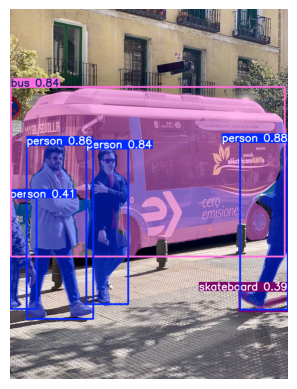

Day 76: Shape of the first mask: (640, 480)


In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 1. Load the Segmentation model
model = YOLO('yolov8n-seg.pt') 

# 2. Predict on the bus image (YOLO handles the download automatically)
results = model.predict('https://ultralytics.com/images/bus.jpg')

# 3. Process the results
for r in results:
    # Plot the result to see the masks visually
    im_array = r.plot()  # plot a BGR numpy array of predictions
    plt.imshow(im_array[..., ::-1]) # Convert BGR to RGB for matplotlib
    plt.axis('off')
    plt.show()

    # Access raw mask data (as polygons or binary masks)
    if r.masks is not None:
        masks = r.masks.data.cpu().numpy() # Binary masks (True/False per pixel)
        print(f"Day 76: Shape of the first mask: {masks[0].shape}")